In [23]:
%pip install pandas
import pandas as pd

df = pd.read_csv("NSE_1001_TO_1050_start_to_15082020.csv")

df.head()

Note: you may need to restart the kernel to use updated packages.


,Unnamed: 0,Date,High,Low,Open,Close,Volume,Adj Close,SYMBOL
0,0,2002-07-01,10.65,9.65,10.65,10.35,463977.0,10.35,SPIC.NS
1,1,2002-07-02,11.60,10.45,10.45,11.40,371253.0,11.40,SPIC.NS
2,2,2002-07-03,12.40,11.40,11.40,11.90,440465.0,11.90,SPIC.NS
3,3,2002-07-04,12.10,11.60,12.00,11.65,87343.0,11.65,SPIC.NS
4,4,2002-07-05,12.25,11.40,11.40,11.55,162943.0,11.55,SPIC.NS


In [24]:
# Assuming your dataframe is 'df' and target is 'Close'
series = df['Close']

split = int(len(series) * 0.8)

train = series[:split]
test = series[split:]

In [25]:
%pip install statsmodels
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(5,1,0))   # example order
model_fit = model.fit()

Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv('NSE_1001_TO_1050_start_to_15082020.csv')

df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df.set_index('Date', inplace=True)

# The ARIMA model was previously on 'total_rides', now setting it to 'Close' for stock data.
# Assuming 'Close' is the column for time series analysis, otherwise please specify.
model = ARIMA(df["Close"], order=(5,1,0))

model_fit = model.fit()

print(model_fit.summary())

c:\Users\prema\OneDrive\Desktop\stock_predications\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\prema\OneDrive\Desktop\stock_predications\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\prema\OneDrive\Desktop\stock_predications\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\prema\OneDrive\Desktop\stock_predications\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it i

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:               122383
Model:                 ARIMA(5, 1, 0)   Log Likelihood             -581547.937
Date:                Tue, 31 Mar 2026   AIC                        1163107.874
Time:                        00:59:07   BIC                        1163166.163
Sample:                             0   HQIC                       1163125.404
                             - 122383                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0090      0.001      6.622      0.000       0.006       0.012
ar.L2          0.0041      0.002      2.483      0.013       0.001       0.007
ar.L3         -0.0092      0.001     -8.685      0.0

In [27]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

# Assuming df['target_column'] is your time series

# Train ARIMA model
model = ARIMA(df['Close'], order=(5,1,0))  # (p,d,q) — adjust if needed
model_fit = model.fit()

# Get next day date
next_day_date = pd.Timestamp.now().normalize()

# Forecast next 1 step
forecast = model_fit.forecast(steps=1)

# Create output DataFrame (same format as yours)
prediction_df = pd.DataFrame({
    'Date': [next_day_date],
    'Predicted Value': [forecast.iloc[0]]
})

display(prediction_df.set_index('Date'))

c:\Users\prema\OneDrive\Desktop\stock_predications\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\prema\OneDrive\Desktop\stock_predications\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\prema\OneDrive\Desktop\stock_predications\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\prema\OneDrive\Desktop\stock_predications\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it i

,Predicted Value
Date,
2026-03-31,1508.509907


In [28]:
current_date = pd.Timestamp.now().normalize()
future_week_dates = pd.date_range(current_date, periods=7)

# The future_week_data and features_for_prediction were intended for exogenous variables,
# but the ARIMA model was not fitted with them. For forecasting, we use model_fit.forecast().
# Therefore, the following lines are no longer needed for a simple forecast:
# future_week_data = pd.DataFrame(index=future_week_dates)
# future_week_data['year'] = future_week_data.index.year
# future_week_data['month'] = future_week_data.index.month
# future_week_data['day'] = future_week_data.index.day
# future_week_data['dayofweek'] = future_week_data.index.dayofweek
# future_week_data['dayofyear'] = future_week_data.index.dayofyear
# future_week_data['weekofyear'] = future_week_data.index.isocalendar().week.astype(int)

# features_for_prediction = [
#     'year','month','day','dayofweek',
#     'dayofyear','weekofyear'
# ]

# Use the fitted model (model_fit) to forecast for the next 7 steps
weekly_predictions_series = model_fit.forecast(steps=len(future_week_dates))

weekly_prediction_df = pd.DataFrame({
    'Date': future_week_dates,
    'Predicted Value': weekly_predictions_series.values # Extract values from the Series
})

# Create yearly predictions for 2026 (365 days)
future_year_dates = pd.date_range(current_date, periods=365)
yearly_predictions_series = model_fit.forecast(steps=len(future_year_dates))

yearly_prediction_df_2026 = pd.DataFrame({
    'Date': future_year_dates,
    'Predicted Value': yearly_predictions_series.values
})

display(weekly_prediction_df.set_index('Date'))
display(yearly_prediction_df_2026.set_index('Date'))

c:\Users\prema\OneDrive\Desktop\stock_predications\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\prema\OneDrive\Desktop\stock_predications\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\prema\OneDrive\Desktop\stock_predications\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,Predicted Value
Date,
2026-03-31,1508.509907
2026-04-01,1508.330609
2026-04-02,1508.270204
2026-04-03,1508.281882
2026-04-04,1508.280798
2026-04-05,1508.281596
2026-04-06,1508.280867


,Predicted Value
Date,
2026-03-31,1508.509907
2026-04-01,1508.330609
2026-04-02,1508.270204
2026-04-03,1508.281882
2026-04-04,1508.280798
...,...
2027-03-26,1508.280697
2027-03-27,1508.280697
2027-03-28,1508.280697


Note: you may need to restart the kernel to use updated packages.


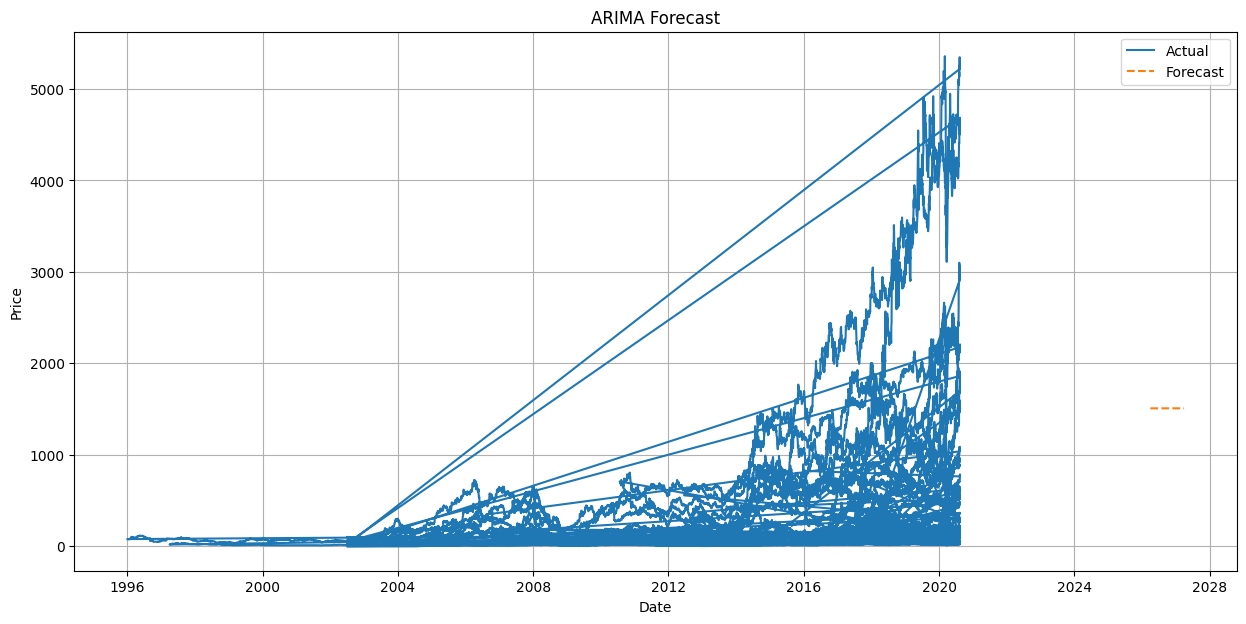

Latest Price: 1508.45
End Forecast Price: 1508.28


In [29]:
%pip install matplotlib
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(15,7))

plt.plot(df.index, df['Close'], label='Actual')
plt.plot(yearly_prediction_df_2026['Date'],
         yearly_prediction_df_2026['Predicted Value'],
         '--', label='Forecast')

plt.title('ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()

plt.show()

# Summary
last_price = df['Close'].iloc[-1]
forecast_price = yearly_prediction_df_2026['Predicted Value'].iloc[-1]

print("Latest Price:", round(last_price, 2))
print("End Forecast Price:", round(forecast_price, 2))

In [30]:
import pandas as pd

# Assuming yearly_prediction_df_2026 contains the forecast data
# and has 'Date' and 'Predicted Value' columns.
# Create a new DataFrame with the desired column names and index
forecast_to_save = yearly_prediction_df_2026.rename(columns={'Predicted Value': 'predicted_means'})
forecast_to_save.set_index('Date', inplace=True)
forecast_to_save.index.name = 'service_date'

forecast_to_save.to_csv("Arima.csv")
print("Predictions saved to Arima.csv")

Predictions saved to Arima.csv
